In [66]:
import pandas as pd
import datetime as dt
import yfinance as yf
import numpy as np

In [67]:
start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,27)

symbol = "INFY.NS"
stk_data = yf.download(symbol,start=start,end=end)
stk_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,,
2021-07-01,1359.065552,1373.393007,1357.889760,1373.393007,4814317
2021-07-02,1365.510742,1366.947762,1343.562171,1357.802550,5166064
2021-07-05,1375.221924,1380.491350,1359.631602,1366.686458,4058338
2021-07-06,1360.633179,1382.015596,1356.191240,1370.649362,4089574
2021-07-07,1362.723755,1367.906106,1345.347893,1363.986729,4797120


In [68]:
stk_data = stk_data[["Open","High","Low","Close"]]
stk_data

Price,Open,High,Low,Close
Ticker,INFY.NS,INFY.NS,INFY.NS,INFY.NS
Date,,,,
2021-07-01,1373.393007,1373.393007,1357.889760,1359.065552
2021-07-02,1357.802550,1366.947762,1343.562171,1365.510742
2021-07-05,1366.686458,1380.491350,1359.631602,1375.221924
2021-07-06,1370.649362,1382.015596,1356.191240,1360.633179
2021-07-07,1363.986729,1367.906106,1345.347893,1362.723755
...,...,...,...,...
2022-01-19,1683.572817,1683.572817,1636.870345,1640.560913
2022-01-20,1620.307084,1623.821850,1595.264377,1602.469604


In [69]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1 = Ms.fit_transform(stk_data[["Close"]])
print(data1.shape)

(143, 1)


In [70]:
orders = [(1,0,1),(2,0,1),(1,1,1),(2,1,2)]
for order in orders:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    model = SARIMAX(data1,order=order,seasonal_order=(1,1,1,12))
    model_fit = model.fit()
    y_pred = model_fit.predict(0,len(data1)-1)
    print(order)

(1, 0, 1)


c:\Users\Paul\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 0, 1)
(1, 1, 1)
(2, 1, 2)


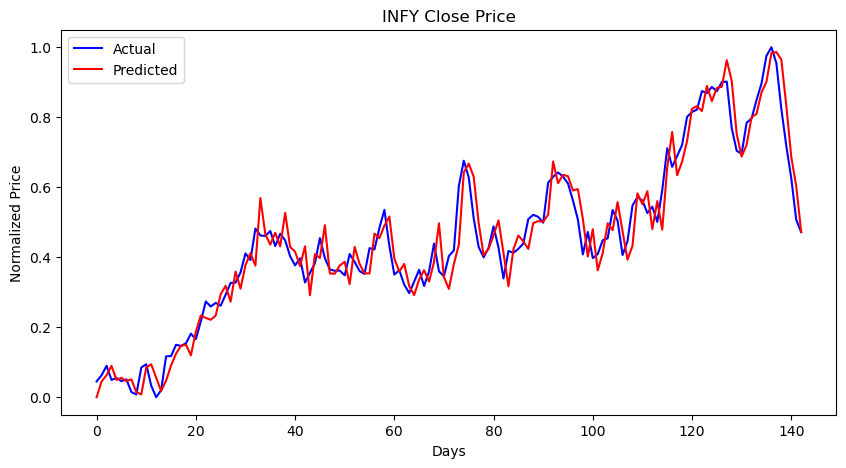

In [71]:
def graph(Actual,predicted,Actlabel,predlabel,title,Xlabel,ylabel):
    from matplotlib import pyplot as plt
    plt.figure(figsize=(10,5))
    plt.plot(Actual, color = 'blue', label=Actlabel)
    plt.plot(predicted, color = 'red', label =predlabel)
    plt.title(title)
    plt.xlabel(Xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()
    
graph(data1,y_pred,"Actual","Predicted","INFY Close Price","Days","Normalized Price")

In [72]:
def split_sequences(sequences, n_steps_in, n_steps_out):
    X, y = list(), list()
    for i in range(len(sequences)):
    # find the end of this pattern
        end_ix = i + n_steps_in
        out_end_ix = end_ix + n_steps_out
        # check if we are beyond the dataset
        if out_end_ix > len(sequences):
            break
        # gather input and output parts of the pattern
        seq_x, seq_y = sequences[i:end_ix, :], sequences[end_ix:out_end_ix, :]
        X.append(seq_x)
        y.append(seq_y)
        from numpy import array
    return array(X), array(y)

def conversion(y_train,stk_data):
    import pandas as pd
    Actual_y_train=pd.DataFrame(index=range(len(y_train)),columns=stk_data.columns)
    for i in range(len(y_train)):
        Actual_y_train.iloc[i]=y_train[i]
    return Actual_y_train

In [73]:
def conversionSingle(y_train,stk_data):
    import pandas as pd
    Actual_y_train=pd.DataFrame(index=range(len(y_train)),columns=stk_data)
    for i in range(len(y_train)):
        Actual_y_train.iloc[i]=y_train[i]
    return Actual_y_train

aTestNormTable = conversionSingle(data1,["Close"])
actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)

actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori,["Close"])

In [74]:
pTestNormTable = conversionSingle(y_pred,["Close"])
predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori,["Close"])

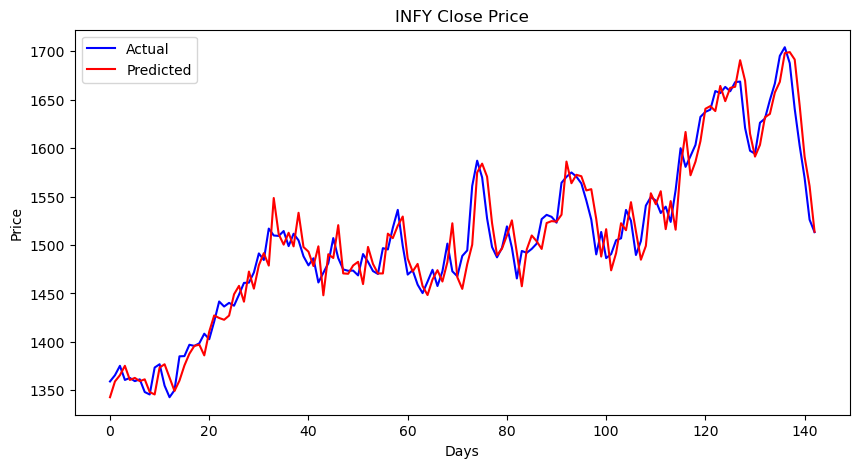

In [75]:
graph(actual_stock_price_test_oriA,predicted_stock_price_test_oriP,"Actual","Predicted","INFY Close Price","Days","Price")

In [76]:
 
def rmsemape(y_Test,predicted_stock_price_test_ori):
    from sklearn.metrics import mean_squared_error
    print("RMSE-Testset:",mean_squared_error(y_Test,predicted_stock_price_test_ori,squared=False))
    #print("RMSE-Trainset:",mean_squared_error(y_Train,predicted_stock_price_train_ori,squared=False))
    from sklearn.metrics import mean_absolute_percentage_error
    print("maPe-Testset:",mean_absolute_percentage_error(y_Test,predicted_stock_price_test_ori))
    #print("mape-Trainset:",mean_absolute_percentage_error(y_Train,predicted_stock_price_train_ori))
    rmsemape(

    actual_stock_price_test_oriA,
    predicted_stock_price_test_oriP
)
forecast = model_fit.predict(len(data1),len(data1)+4)
forecast

array([0.51341636, 0.51465838, 0.54393244, 0.55996957, 0.58346524])

In [77]:
fTestNormTable = conversionSingle(forecast,["Forecast"])
forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori,["Forecast"])

In [78]:
forecast_stock_price_test_oriF.to_csv("INFY_SARIMA_Forecast.csv",index=False)

In [79]:
forecast_stock_price_test_oriF

,Forecast
0,1528.349378
1,1528.798299
2,1539.379223
3,1545.175738
4,1553.668098


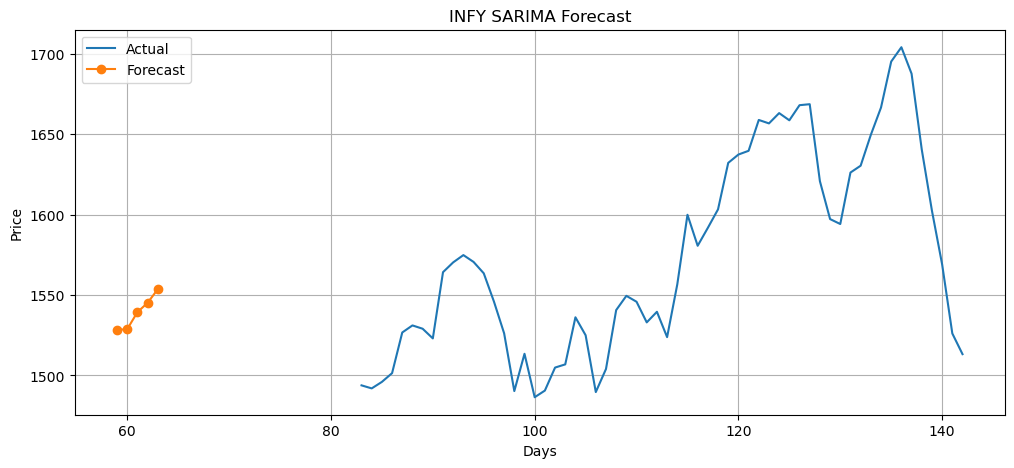

SARIMA Forecast Completed Successfully.


In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(actual_stock_price_test_oriA.tail(60),label="Actual")
future_x = range(59,59 + len(forecast_stock_price_test_oriF))
plt.plot(future_x,forecast_stock_price_test_oriF,marker="o",label="Forecast")

plt.title("INFY SARIMA Forecast")
plt.xlabel("Days")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.show()

print("SARIMA Forecast Completed Successfully.")